# Модель 2: Extra Trees Regressor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from joblib import dump
import os
import time
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv(os.path.join('../data/normalized_inputs_and_targets_gsf.csv'))

feature_columns = [
    '0in_norm', '2in_norm', '3in_norm', '5in_norm', '6in_norm',
    '8in_norm', '10in_norm', '12in_norm', '15in_norm', '18in_norm'
]

target_columns = [f'E{i}_norm' for i in range(1, 61)]

X = data[feature_columns]
y = data[target_columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape[0]} образцов")
print(f"Размер тестовой выборки: {X_test.shape[0]} образцов")

Размер обучающей выборки: 350499 образцов
Размер тестовой выборки: 150214 образцов


In [2]:
et_model = ExtraTreesRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

print("\nНачало обучения Extra Trees...")
start_time = time.time()
et_model.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"Обучение завершено за {training_time:.2f} секунд")

print("\nПредсказание на тестовой выборке...")
start_time = time.time()
y_pred = et_model.predict(X_test)
prediction_time = time.time() - start_time
print(f"Предсказание завершено за {prediction_time:.2f} секунд")

print("\n" + "=" * 70)
print("ОЦЕНКА КАЧЕСТВА EXTRA TREES")
print("=" * 70)

mse_scores = []
rmse_scores = []
mae_scores = []
r2_scores = []

print(f"\n{'Цель':<10} {'MSE':<15} {'RMSE':<15} {'MAE':<15} {'R2':<10}")
print("-" * 70)

for i, target in enumerate(target_columns):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    mse_scores.append(mse)
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

    print(f"{target:<10} {mse:<15.4f} {rmse:<15.4f} {mae:<15.4f} {r2:<10.4f}")

print("-" * 70)

print("\nСРЕДНИЕ МЕТРИКИ ПО ВСЕМ ЦЕЛЯМ:")
print(f"Средний MSE:  {np.mean(mse_scores):.4f} (±{np.std(mse_scores):.4f})")
print(f"Средний RMSE: {np.mean(rmse_scores):.4f} (±{np.std(rmse_scores):.4f})")
print(f"Средний MAE:  {np.mean(mae_scores):.4f} (±{np.std(mae_scores):.4f})")
print(f"Средний R²:   {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.4f})")

print("\n" + "=" * 70)
print("ИНФОРМАЦИЯ О МОДЕЛИ")
print("=" * 70)
print(f"Количество деревьев: {et_model.n_estimators}")
print(f"Используемые признаки: {feature_columns}")
print(f"Количество целевых переменных: {len(target_columns)}")

print("\nВажность признаков:")
feature_importance = pd.DataFrame({
    'Признак': feature_columns,
    'Важность': et_model.feature_importances_
}).sort_values('Важность', ascending=False)

for idx, row in feature_importance.iterrows():
    print(f"  {row['Признак']}: {row['Важность']:.4f}")

dump(et_model, 'models/extra_trees_model.joblib')
print(f"\nМодель сохранена в файл: models/extra_trees_model.joblib")


Начало обучения Extra Trees...
Обучение завершено за 25.62 секунд

Предсказание на тестовой выборке...
Предсказание завершено за 1.17 секунд

ОЦЕНКА КАЧЕСТВА EXTRA TREES

Цель       MSE             RMSE            MAE             R2        
----------------------------------------------------------------------
E1_norm    0.0008          0.0283          0.0080          0.6402    
E2_norm    0.0014          0.0373          0.0099          0.7612    
E3_norm    0.0015          0.0387          0.0118          0.8633    
E4_norm    0.0014          0.0367          0.0142          0.9366    
E5_norm    0.0009          0.0292          0.0154          0.9651    
E6_norm    0.0014          0.0380          0.0195          0.9455    
E7_norm    0.0017          0.0408          0.0221          0.9332    
E8_norm    0.0025          0.0498          0.0227          0.9106    
E9_norm    0.0026          0.0509          0.0214          0.8964    
E10_norm   0.0019          0.0440          0.0206        

In [3]:
reference_spectrum = {
    "E_MeV": [
        1e-09, 1.5848931924611136e-09, 2.5118864315095803e-09,
        3.981071705534973e-09, 6.309573444801934e-09, 1e-08,
        1.5848931924611143e-08, 2.511886431509581e-08,
        3.9810717055349736e-08, 6.309573444801934e-08,
        1.0000000000000001e-07, 1.5848931924611143e-07,
        2.5118864315095823e-07, 3.9810717055349735e-07,
        6.309573444801937e-07, 1.0000000000000002e-06,
        1.584893192461114e-06, 2.5118864315095823e-06,
        3.981071705534973e-06, 6.309573444801937e-06,
        1e-05, 1.584893192461114e-05, 2.5118864315095822e-05,
        3.9810717055349776e-05, 6.309573444801943e-05,
        0.0001, 0.00015848931924611142, 0.0002511886431509582,
        0.0003981071705534978, 0.0006309573444801943,
        0.001, 0.0015848931924611143, 0.0025118864315095825,
        0.003981071705534978, 0.006309573444801942,
        0.01, 0.01584893192461114, 0.025118864315095826,
        0.039810717055349776, 0.06309573444801943,
        0.1, 0.15848931924611173, 0.25118864315095824,
        0.3981071705534969, 0.6309573444801944,
        1.0, 1.5848931924611174, 2.5118864315095824,
        3.9810717055349856, 6.309573444801943,
        10.0, 15.848931924611176, 25.118864315095824,
        39.810717055349855, 63.09573444801943,
        100.0, 158.48931924611173, 251.18864315095823,
        398.1071705534986, 630.9573444801944,
    ]
}


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

Построение графика для образца #5...
График сохранен в файл: ../results/et_spectrum_comparison_sample_5.png


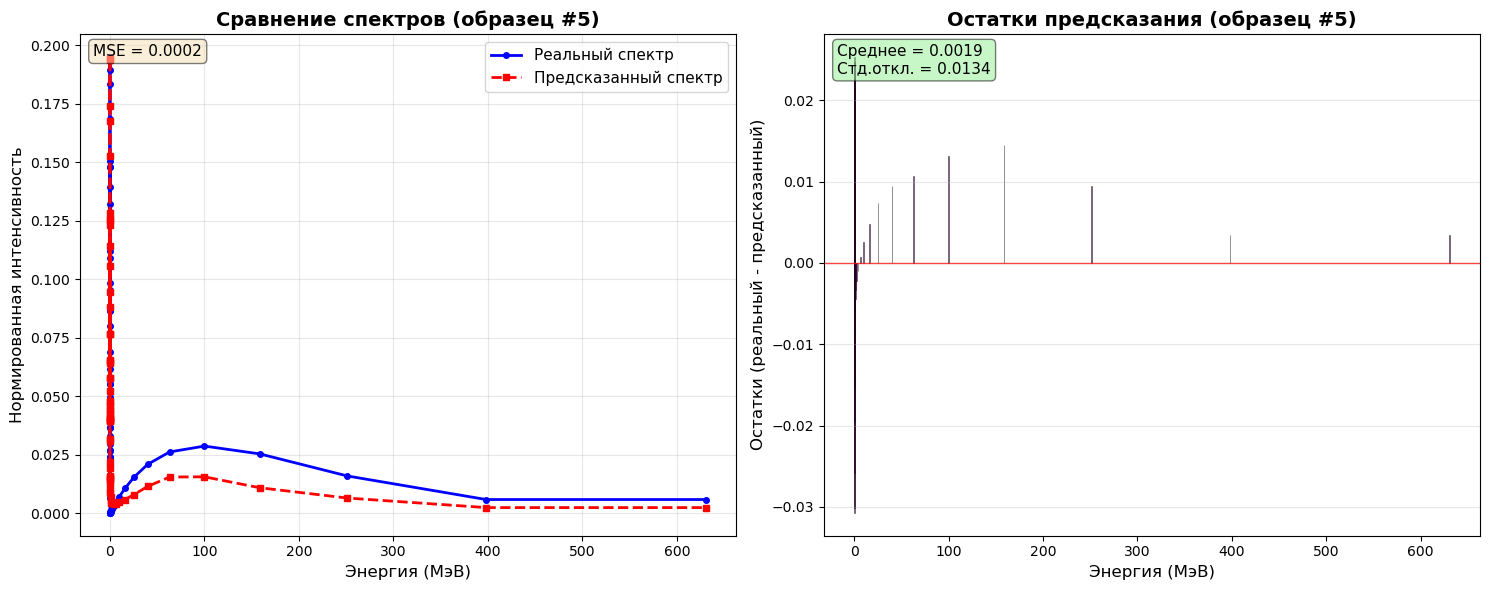


Построение сравнительных графиков для нескольких образцов...


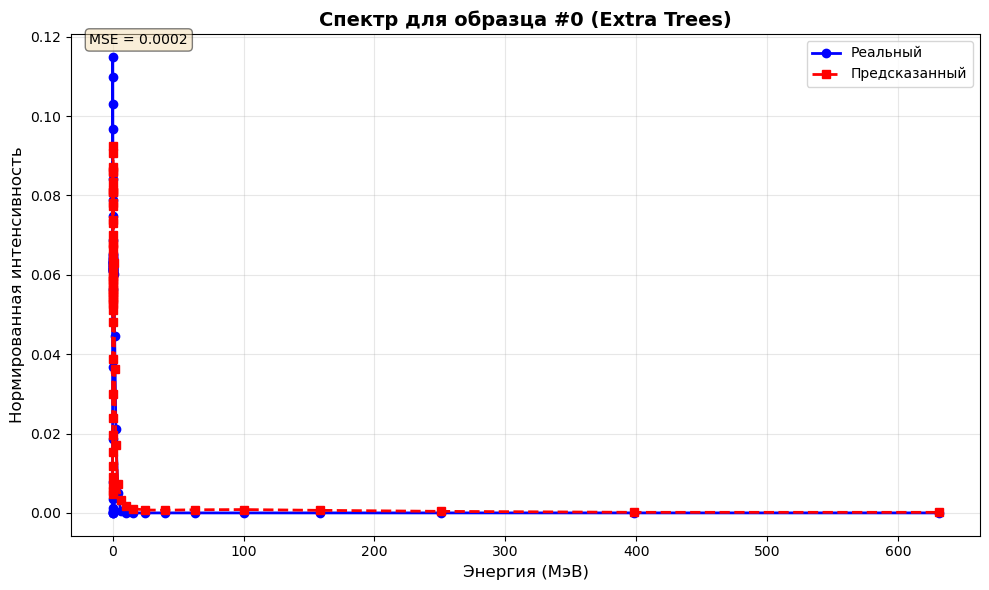

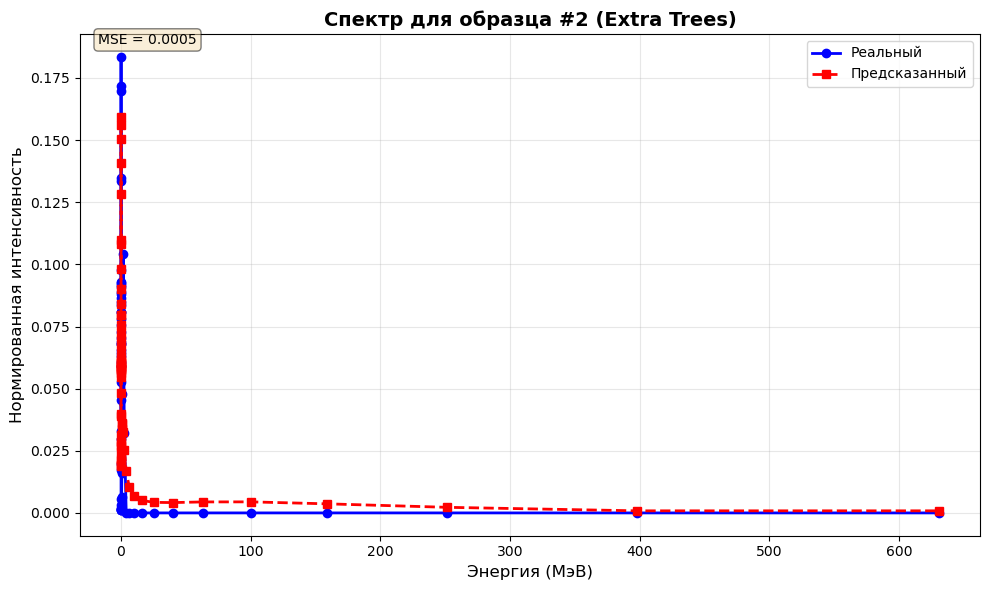

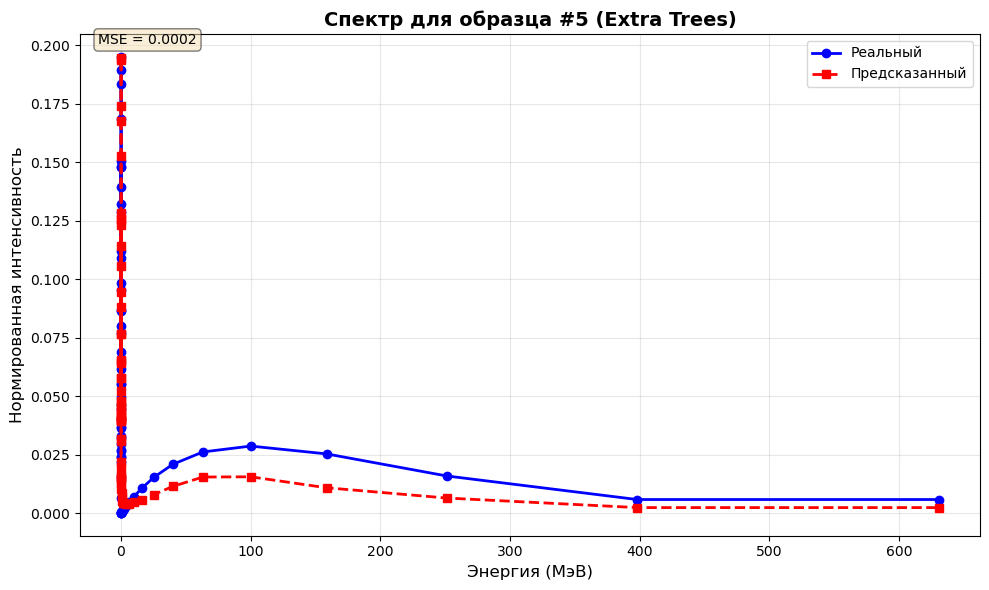

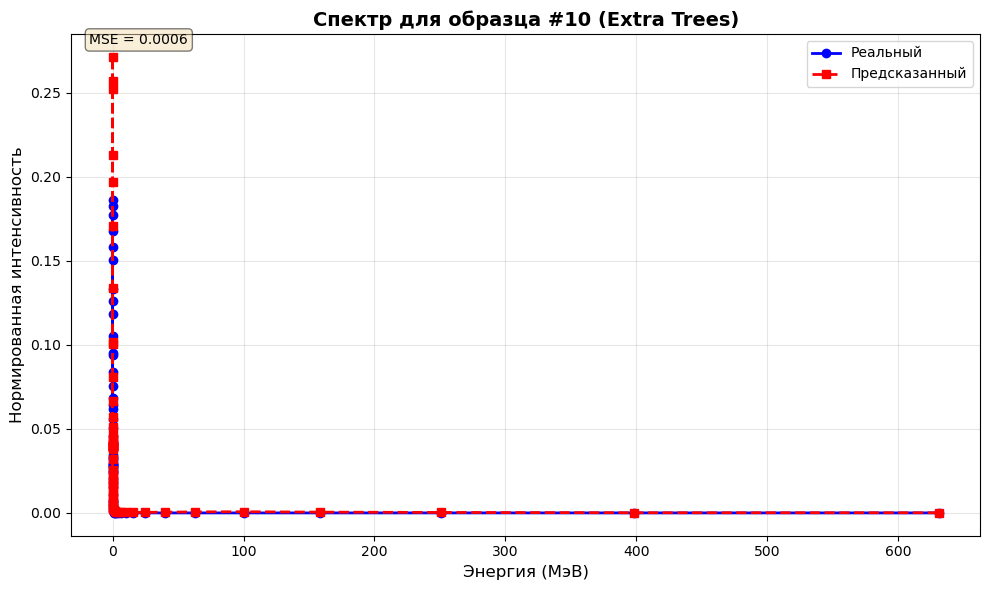

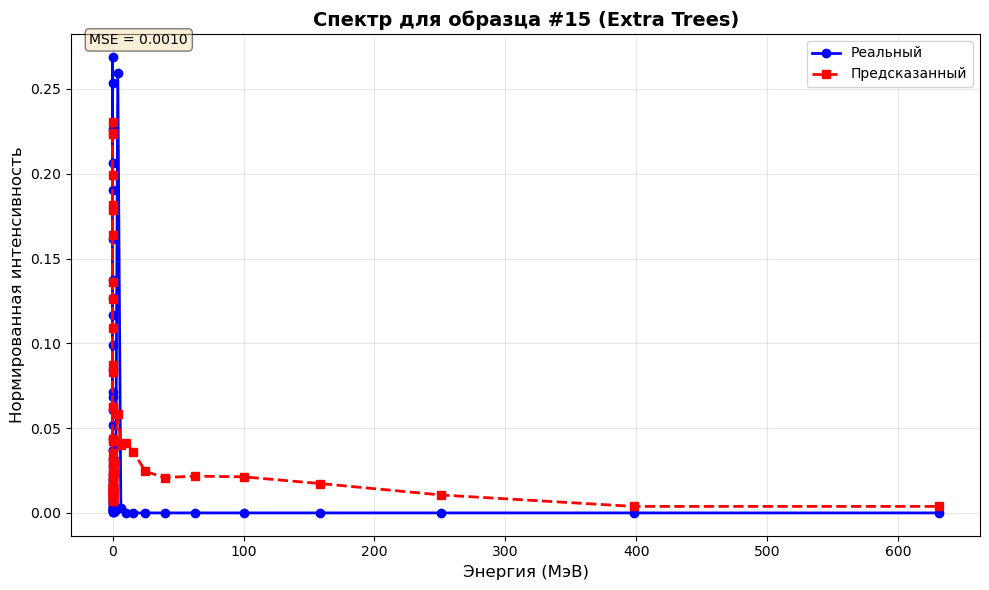

In [4]:
def plot_spectrum_comparison(reference_spectrum, y_true, y_pred, sample_index=5, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax1 = axes[0]

    energies = reference_spectrum['E_MeV']
    true_spectrum = y_true.iloc[sample_index].values
    pred_spectrum = y_pred[sample_index]

    ax1.plot(energies, true_spectrum, 'b-', linewidth=2, label='Реальный спектр', marker='o', markersize=4)
    ax1.plot(energies, pred_spectrum, 'r--', linewidth=2, label='Предсказанный спектр', marker='s', markersize=4)

    ax1.set_xlabel('Энергия (МэВ)', fontsize=12)
    ax1.set_ylabel('Нормированная интенсивность', fontsize=12)
    ax1.set_title(f'Сравнение спектров (образец #{sample_index})', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    mse_sample = np.mean((true_spectrum - pred_spectrum)**2)
    ax1.text(0.02, 0.98, f'MSE = {mse_sample:.4f}',
             transform=ax1.transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax2 = axes[1]

    residuals = true_spectrum - pred_spectrum

    ax2.bar(energies, residuals, width=0.8, color='purple', alpha=0.6, edgecolor='black', linewidth=0.5)
    ax2.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.7)

    ax2.set_xlabel('Энергия (МэВ)', fontsize=12)
    ax2.set_ylabel('Остатки (реальный - предсказанный)', fontsize=12)
    ax2.set_title(f'Остатки предсказания (образец #{sample_index})', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    ax2.text(0.02, 0.98, f'Среднее = {mean_residual:.4f}\nСтд.откл. = {std_residual:.4f}',
             transform=ax2.transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"График сохранен в файл: {save_path}")

    plt.show()

    return fig

print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 70)

print("\nПостроение графика для образца #5...")
plot_spectrum_comparison(
    reference_spectrum=reference_spectrum,
    y_true=y_test,
    y_pred=y_pred,
    sample_index=5,
    save_path='../results/et_spectrum_comparison_sample_5.png'
)

print("\nПостроение сравнительных графиков для нескольких образцов...")

sample_indices = [0, 2, 5, 10, 15]

for idx in sample_indices:
    if idx < len(X_test):
        plt.figure(figsize=(10, 6))

        energies = reference_spectrum['E_MeV']
        true_vals = y_test.iloc[idx].values
        pred_vals = y_pred[idx]

        plt.plot(energies, true_vals, 'b-', linewidth=2, label='Реальный', marker='o')
        plt.plot(energies, pred_vals, 'r--', linewidth=2, label='Предсказанный', marker='s')

        plt.xlabel('Энергия (МэВ)', fontsize=12)
        plt.ylabel('Нормированная интенсивность', fontsize=12)
        plt.title(f'Спектр для образца #{idx} (Extra Trees)', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)

        mse_val = np.mean((true_vals - pred_vals)**2)
        plt.text(0.02, 0.98, f'MSE = {mse_val:.4f}',
                 transform=plt.gca().transAxes, fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.tight_layout()
        plt.savefig(f'../results/et_spectrum_sample_{idx}.png', dpi=300, bbox_inches='tight')
        plt.show()